# Training 1D CNN Model on UCI-HAR Dataset

Notebook ini train 1D-CNN pada UCI-HAR dataset. Setelah training, di export ke format tflite dan dicompile menggunakan Vela Compiler untuk deployment di NPU Arm Ethos-U55

In [1]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "scripts":
    PROJECT_DIR = PROJECT_DIR.parent

MODEL_DIR = PROJECT_DIR / "model"
VELA_OUT_DIR = PROJECT_DIR / "vela_out_u55_64"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
VELA_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Model dir:", MODEL_DIR)

I0000 00:00:1783577603.195725    2467 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783577603.196292    2467 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783577603.249204    2467 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783577604.532028    2467 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Python: /path/to/uci-har-grove-vision-ai-v2/.venv/bin/python
TensorFlow: 2.21.0
Project dir: /path/to/uci-har-grove-vision-ai-v2
Model dir: /path/to/uci-har-grove-vision-ai-v2/model


### 1. Inspect Raw Data and Columns
Inspect salah satu file sinyal (body_acc_x)

In [2]:
# Cek kolom dan beberapa baris pertama dari file body_acc_x_train.txt
csv_path = PROJECT_DIR / 'dataset' / 'UCI HAR Dataset' / 'train' / 'Inertial Signals' / 'body_acc_x_train.txt'
df_sample = pd.read_csv(csv_path, sep=r'\s+', header=None, nrows=100)

print("Columns in df_sample (first 10 shown):")
print(list(df_sample.columns[:10]))

display(df_sample.iloc[:, :10].head())

Columns in df_sample (first 10 shown):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


,0,1,2,3,4,5,6,7,8,9
0,0.000181,0.010139,0.009276,0.005066,0.010810,0.004045,0.004757,0.006214,0.003307,0.007572
1,0.001094,0.004550,0.002879,0.002247,0.003305,0.002416,0.001619,0.000981,0.000009,-0.000363
2,0.003531,0.002285,-0.000420,-0.003738,-0.006706,-0.003148,0.000733,0.000668,0.002162,-0.000946
3,-0.001772,-0.001311,0.000388,0.000408,-0.000355,0.000998,0.001109,-0.003149,-0.008882,-0.010483
4,0.000087,-0.000272,0.001022,0.003126,0.002284,0.000885,0.001933,0.002270,0.002247,0.002175


### 2. Print Total Rows and Columns
Melihat total dimensi dari dataset sampel

In [3]:
# Total baris dan kolom dataset
df_full = pd.read_csv(csv_path, sep=r'\s+', header=None)
print("Total rows:", df_full.shape[0])
print("Total columns:", df_full.shape[1])

Total rows: 7352
Total columns: 128


### 3. Activity Label Counts & Mapping
Mengubah label dari 1-6 ke 0-5

In [4]:
# Label mapping: ubah label ke numerik 0..5
y_path = PROJECT_DIR / 'dataset' / 'UCI HAR Dataset' / 'train' / 'y_train.txt'
df_y = pd.read_csv(y_path, sep=r'\s+', header=None, names=["activity_id"])

print("Original label counts:")
print(df_y["activity_id"].value_counts().sort_index())

df_y["label_id"] = df_y["activity_id"] - 1

activity_labels_path = PROJECT_DIR / 'dataset' / 'UCI HAR Dataset' / 'activity_labels.txt'
df_act = pd.read_csv(activity_labels_path, sep=r'\s+', header=None, names=["id", "name"])
label_mapping = {int(row["id"]): row["name"] for _, row in df_act.iterrows()}

print("\nLabel mapping:")
print(label_mapping)

print("\nLabel ID counts:")
print(df_y["label_id"].value_counts().sort_index())

NUM_CLASSES = df_y["label_id"].nunique()
print("\nNUM_CLASSES:", NUM_CLASSES)

# Save label mapping ke JSON
label_mapping_path = MODEL_DIR / "uci_har_label_mapping.json"
with open(label_mapping_path, "w") as f:
    json.dump(label_mapping, f, indent=4)
print("Saved label mapping to:", label_mapping_path)

Original label counts:
activity_id
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64

Label mapping:
{1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}

Label ID counts:
label_id
0    1226
1    1073
2     986
3    1286
4    1374
5    1407
Name: count, dtype: int64

NUM_CLASSES: 6
Saved label mapping to: /path/to/uci-har-grove-vision-ai-v2/model/uci_har_label_mapping.json


### 4. Load the Full Dataset
Load semua raw inertial signals

In [5]:
DATADIR = PROJECT_DIR / 'dataset' / 'UCI HAR Dataset'
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]

def load_signals(subset):
    signals_data = []
    for signal in SIGNALS:
        filename = DATADIR / subset / 'Inertial Signals' / f"{signal}_{subset}.txt"
        signals_data.append(
            pd.read_csv(filename, sep=r'\s+', header=None).to_numpy()
        )
    return np.transpose(signals_data, (1, 2, 0))

X_train = load_signals('train')
X_test = load_signals('test')
y_train = (pd.read_csv(DATADIR / 'train' / 'y_train.txt', sep=r'\s+', header=None)[0] - 1).to_numpy()
y_test = (pd.read_csv(DATADIR / 'test' / 'y_test.txt', sep=r'\s+', header=None)[0] - 1).to_numpy()

print("Loading dataset...")
print("Loaded X_train shape:", X_train.shape)
print("Loaded y_train shape:", y_train.shape)
print("Loaded X_test shape:", X_test.shape)
print("Loaded y_test shape:", y_test.shape)

Loading dataset...
Loaded X_train shape: (7352, 128, 9)
Loaded y_train shape: (7352,)
Loaded X_test shape: (2947, 128, 9)
Loaded y_test shape: (2947,)


### 5. Split Train and Validation Sets
Split data training menjadi train and validation (80% / 20%).

In [6]:
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("X_train_split shape:", X_train_split.shape)
print("X_val_split shape:", X_val_split.shape)

X_train_split shape: (5881, 128, 9)
X_val_split shape: (1471, 128, 9)


### 6. Define the 1D CNN Model Architecture
1D CNN model yang cocok untuk deployment ke NPU Ethos-U55

In [7]:
from tensorflow.keras import layers, models

WINDOW_SIZE = 128
NUM_CHANNELS = len(SIGNALS)

model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, NUM_CHANNELS)),
    layers.Conv1D(16, kernel_size=5, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(32, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

E0000 00:00:1783577608.283771    2467 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783577608.284415    4222 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783577608.308386    2467 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 16)        │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,302 (137.90 KB)

 Trainable params: 35,302 (137.90 KB)

 Non-trainable params: 0 (0.00 B)

### 7. Train the Model
Model ditraining 20 epoch.

In [8]:
# Training model
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6679 - loss: 0.7937 - val_accuracy: 0.8865 - val_loss: 0.3691
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8879 - loss: 0.3090 - val_accuracy: 0.9436 - val_loss: 0.1942
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9272 - loss: 0.2104 - val_accuracy: 0.9511 - val_loss: 0.1530
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9366 - loss: 0.1723 - val_accuracy: 0.9470 - val_loss: 0.1467
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9459 - loss: 0.1477 - val_accuracy: 0.9599 - val_loss: 0.1220
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9471 - loss: 0.1459 - val_accuracy: 0.9606 - val_loss: 0.1196
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9514 - loss: 0.1300 - val_accuracy: 0.9545 - val_loss: 0.1142
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9492 - loss: 0.1239 - val_accuracy: 0

### 8. Plot Training History
Plotting akurasi train dan validasi, dan trend loss

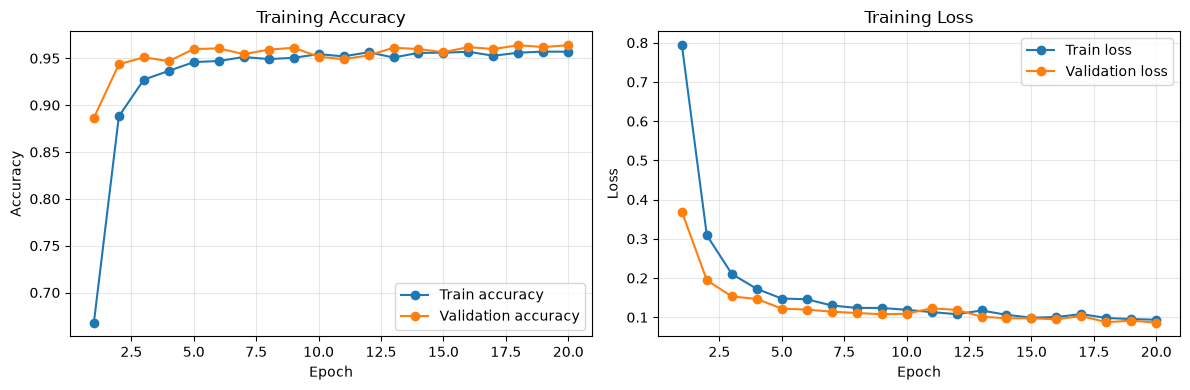

Saved training history plot to: /path/to/uci-har-grove-vision-ai-v2/model/uci_har_training_history.png


In [9]:
# Plot training history
import matplotlib.pyplot as plt

history_dict = history.history
epochs_range = range(1, len(history_dict[
"loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_dict["accuracy"], marker="o", label="Train accuracy")
plt.plot(epochs_range, history_dict["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_dict["loss"], marker="o", label="Train loss")
plt.plot(epochs_range, history_dict["val_loss"], marker="o", label="Validation loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plot_path = MODEL_DIR / "uci_har_training_history.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved training history plot to:", plot_path)

### 9. Evaluate Model Performance on Test Set
Menghitung akurasi dan loss di set test

In [10]:
# Evaluasi Model: Akurasi dan test loss
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.33523043990135193
Test accuracy: 0.9222938418388367


### 10. Classification Report & Confusion Matrix
Dibuat confusion matrix dan classification report

In [11]:
# Evaluasi Model: Confusion Matrix dan Classification Report
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
[[486   7   3   0   0   0]
 [  6 459   6   0   0   0]
 [  3   5 412   0   0   0]
 [  0  17   0 375  99   0]
 [  0   4   0  53 475   0]
 [  0  26   0   0   0 511]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       496
           1       0.89      0.97      0.93       471
           2       0.98      0.98      0.98       420
           3       0.88      0.76      0.82       491
           4       0.83      0.89      0.86       532
           5       1.00      0.95      0.98       537

    accuracy                           0.92      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.92      0.92      0.92      2947



In [12]:
# ============================================================
# Evaluate INT8 TFLite Model
# ============================================================

import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TFLITE_MODEL = MODEL_DIR / "uci_har_model_int8.tflite"

# Load interpreter
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input :", input_details[0]["shape"])
print("Output:", output_details[0]["shape"])

input_scale, input_zero_point = input_details[0]["quantization"]

print("\nInput Quantization")
print("Scale      :", input_scale)
print("Zero Point :", input_zero_point)

predictions = []

for sample in X_test:

    x = sample[np.newaxis, ...]

    # Quantize
    x = np.round(x / input_scale + input_zero_point)
    x = np.clip(x, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], x)

    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])

    predictions.append(np.argmax(output))

predictions = np.array(predictions)

accuracy = accuracy_score(y_test, predictions)

print("\n===================================")
print("INT8 Accuracy :", accuracy)
print("===================================\n")

print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
print(cm)

Input : [  1 128   9]
Output: [1 6]

Input Quantization
Scale      : 0.022215694189071655
Zero Point : 31

INT8 Accuracy : 0.9158466236851035

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       496
           1       0.88      0.94      0.91       471
           2       0.90      1.00      0.95       420
           3       0.83      0.82      0.83       491
           4       0.88      0.84      0.86       532
           5       1.00      0.95      0.98       537

    accuracy                           0.92      2947
   macro avg       0.92      0.92      0.92      2947
weighted avg       0.92      0.92      0.92      2947

[[472   1  23   0   0   0]
 [  2 444  25   0   0   0]
 [  0   0 420   0   0   0]
 [  0  27   0 404  60   0]
 [  0   4   0  80 448   0]
 [  0  26   0   0   0 511]]


/path/to/uci-har-grove-vision-ai-v2/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### 11. Save Keras Model
Save model floating point yang sudah di train

In [13]:
# Save Keras model
keras_model_path = MODEL_DIR / "uci_har_model_fp32.keras"
model.save(keras_model_path)
print("Saved Keras model to:", keras_model_path)

Saved Keras model to: /path/to/uci-har-grove-vision-ai-v2/model/uci_har_model_fp32.keras


### 12. Convert Keras Model to TFLite INT8 Quantized Format
Dilakukan post training int quantization

In [14]:
# Convert Keras model to TFLite int8 model
def representative_dataset():
    for i in range(min(100, len(X_train))):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()

tflite_path = MODEL_DIR / "uci_har_model_int8.tflite"

with open(tflite_path, "wb") as f:
    f.write(tflite_int8_model)

print("Saved TFLite int8 model to:", tflite_path)
print("Size:", tflite_path.stat().st_size, "bytes")

INFO:tensorflow:Assets written to: /tmp/tmp3c0rpvah/assets


INFO:tensorflow:Assets written to: /tmp/tmp3c0rpvah/assets


Saved artifact at '/tmp/tmp3c0rpvah'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133999675022160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133999675022928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133999675022544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133999675025424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133999675024272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133999675026000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133999675025808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133999675024656: TensorSpec(shape=(), dtype=tf.resource, name=None)


/path/to/uci-har-grove-vision-ai-v2/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved TFLite int8 model to: /path/to/uci-har-grove-vision-ai-v2/model/uci_har_model_int8.tflite
Size: 45208 bytes


W0000 00:00:1783577634.342308    2467 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783577634.342367    2467 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1783577634.342707    2467 reader.cc:83] Reading SavedModel from: /tmp/tmp3c0rpvah
I0000 00:00:1783577634.343107    2467 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1783577634.343116    2467 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp3c0rpvah
I0000 00:00:1783577634.348435    2467 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1783577634.349323    2467 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1783577634.376953    2467 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp3c0rpvah
I0000 00:00:1783577634.384671    2467 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 41973 microseconds.
I0000 00:00:1783577634.408379    2467

### 13. Verify TFLite Model Signatures
Verifikasi parameter dari model yang sudah dikuantisasi

In [15]:
# Verify TFLite model
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:")
for item in input_details:
    print(item)

print("\nOutput details:")
for item in output_details:
    print(item)

Input details:
{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([  1, 128,   9], dtype=int32), 'shape_signature': array([ -1, 128,   9], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.022215694189071655, 31), 'quantization_parameters': {'scales': array([0.02221569], dtype=float32), 'zero_points': array([31], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}

Output details:
{'name': 'StatefulPartitionedCall_1:0', 'index': 36, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}


/path/to/uci-har-grove-vision-ai-v2/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### 14. Test Inference with a Sample
Run sampel melalui interpreter yang sudah terkuantisasi.

In [16]:
# Test inference with a sample from the test set
input_detail = input_details[0]
output_detail = output_details[0]

sample = X_test[0:1].astype(np.float32)

input_scale, input_zero_point = input_detail["quantization"]

sample_int8 = sample / input_scale + input_zero_point
sample_int8 = np.clip(sample_int8, -128, 127).astype(np.int8)

interpreter.set_tensor(input_detail["index"], sample_int8)
interpreter.invoke()

output_int8 = interpreter.get_tensor(output_detail["index"])

output_scale, output_zero_point = output_detail["quantization"]
output_float = (output_int8.astype(np.float32) - output_zero_point) * output_scale

print("True label:", y_test[0])
print("Raw int8 output:", output_int8)
print("Dequantized output:", output_float)
print("Predicted label:", np.argmax(output_float))

True label: 4
Raw int8 output: [[-128 -128 -128 -128  127 -128]]
Dequantized output: [[0.         0.         0.         0.         0.99609375 0.        ]]
Predicted label: 4


### 15. Compile for Ethos-U55 NPU using Vela Compiler
Compile model INT8 TFLite.

In [17]:
!cd {PROJECT_DIR} && vela model/uci_har_model_int8.tflite --accelerator-config=ethos-u55-64 --system-config=Ethos_U55_High_End_Embedded --memory-mode=Shared_Sram --output-dir=vela_out_u55_64

Tensor 'serving_default_keras_tensor:0' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'sequential_1/conv1d_1/convolution/ExpandDims' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'sequential_1/conv1d_1/Relu;sequential_1/conv1d_1/BiasAdd;sequential_1/conv1d_1/convolution/Squeeze;sequential_1/conv1d_1/Squeeze;sequential_1/conv1d_1/convolution1' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'sequential_1/conv1d_1/Relu;sequential_1/conv1d_1/BiasAdd;sequential_1/conv1d_1/convolution/Squeeze;sequential_1/conv1d_1/Squeeze' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'sequential_1/max_pooling1d_1/MaxPool1d/ExpandDims' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'sequential_1/max_pooling1d_1/MaxPool1d' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'sequential_1/max_p

### 16. Verify Vela Compilation Outputs
Cek file yang sudah dicompile di output directory.

In [18]:
# List files in VELA_OUT_DIR
for f in VELA_OUT_DIR.iterdir():
    if "uci_har" in f.name:
        print(f.name, f.stat().st_size, "bytes")

uci_har_model_int8_vela.tflite 40512 bytes
uci_har_model_int8_summary_Ethos_U55_High_End_Embedded.csv 1549 bytes


In [19]:
from pathlib import Path
import numpy as np

deployment_dir = Path("deployment")
deployment_dir.mkdir(exist_ok=True)

print("Saving deployment dataset...")

np.save(deployment_dir / "X_test.npy", X_test)
np.save(deployment_dir / "y_test.npy", y_test)

print("Saved:")
print(" ", deployment_dir / "X_test.npy")
print(" ", deployment_dir / "y_test.npy")

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)

Saving deployment dataset...


Saved:
  deployment/X_test.npy
  deployment/y_test.npy
X_test: (2947, 128, 9) float64
y_test: (2947,) int64


In [20]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="../model/har_model_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()

print(input_details[0])

{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([  1, 128,   6], dtype=int32), 'shape_signature': array([ -1, 128,   6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.035077206790447235, -1), 'quantization_parameters': {'scales': array([0.03507721], dtype=float32), 'zero_points': array([-1], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}


In [21]:
import tensorflow as tf

MODEL_PATH = "../model/uci_har_model_int8.tflite"

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

print(interpreter.get_input_details()[0])

{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([  1, 128,   9], dtype=int32), 'shape_signature': array([ -1, 128,   9], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.022215694189071655, 31), 'quantization_parameters': {'scales': array([0.02221569], dtype=float32), 'zero_points': array([31], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}
